In [1]:
import os
import sys
import pandas as pd
import numpy as np
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src", "utils"))
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(".")), "..", "..", "..", "src", "prompt"))
import env_loader
env_loader.load_env()
from utils import generate_mixed_violin_plot

In [2]:
WORK_DIR = os.environ.get("WORK_DIR_HOME", "")
results_dir_parent = os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/methods/prompting/train_test/stage2')
agg_df_train = pd.read_csv(f"{results_dir_parent}/aggregate_statistics_stage2.csv", header=0)
agg_df_train

,Target,AUC,n_samples,mean_proba,CI,n_few_shot_added_mean,LLM_name,n_params,quantization_level,quant_ranking,n_few_shot,target_type
0,target-hemoglobin-grade2plus,0.702072,600,0.439083,"[0.662, 0.746]",15.441667,Qwen2.5-3B-Q8-0,3,Q8,6,16,lab
1,target-hemoglobin-grade2plus,0.666750,600,0.493667,"[0.627, 0.707]",15.441667,Qwen2.5-7B-Q8-0,7,Q8,6,16,lab
2,target-hemoglobin-grade2plus,0.681171,599,0.591653,"[0.638, 0.720]",15.440735,Qwen2.5-14B-IQ2-M,14,IQ2,1,16,lab
3,target-hemoglobin-grade2plus,0.639611,600,0.658833,"[0.604, 0.675]",15.441667,Qwen2.5-7B-IQ2-M,7,IQ2,1,16,lab
4,target-hemoglobin-grade2plus,0.587904,576,0.197240,"[0.545, 0.632]",15.467014,Qwen2.5-3B-IQ3-M,3,IQ3,2,16,lab
...,...,...,...,...,...,...,...,...,...,...,...,...
223,target-ED-visit,0.629539,600,0.443417,"[0.588, 0.671]",3.996667,Qwen2.5-7B-IQ3-M,7,IQ3,2,4,clinic
224,target-ED-visit,0.661156,600,0.418000,"[0.620, 0.704]",3.996667,Qwen2.5-7B-Q6-K,7,Q6,5,4,clinic
225,target-ED-visit,0.607078,600,0.454917,"[0.564, 0.650]",3.996667,Qwen2.5-3B-Q4-K-M,3,Q4,4,4,clinic
226,target-ED-visit,0.654967,600,0.421917,"[0.609, 0.700]",3.996667,Qwen2.5-7B-IQ4-XS,7,IQ4,3,4,clinic


In [3]:
quantization_map = {"IQ2": 1,
                    "IQ3": 2,
                    "IQ4": 3,
                    "Q4": 4,
                    "Q6": 5,
                    "Q8": 6}

qwen_best_results = pd.read_csv(os.path.join(WORK_DIR, 'gitrepo/2024/OncoTRAIL/paper/pmh_method/methods/prompting/train_test/stage1/qwen_best_results_stage1.csv'), index_col=0)
qwen_best_results['n_params'] = 14
qwen_best_results['quantization_level'] = "IQ4"
qwen_best_results['quant_ranking'] = quantization_map["IQ4"]
agg_df_train = pd.concat([agg_df_train, qwen_best_results]).reset_index(drop=True)

Significant: Mean difference between 3 and 7: -0.023
  Lab: Mean difference = -0.011
  Symptom: Mean difference = -0.024
  Clinic: Mean difference = -0.052
Significant: Mean difference between 3 and 14: -0.062
  Lab: Mean difference = -0.073
  Symptom: Mean difference = -0.020
  Clinic: Mean difference = -0.084


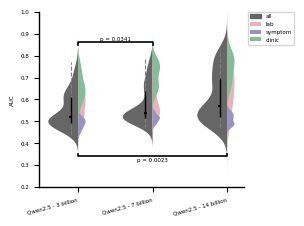

In [4]:
# fig=generate_mixed_violin_plot(agg_df_train, 'n_params', 0, ["Qwen2.5 - 3 billion", "Qwen2.5 - 7 billion", "Qwen2.5 - 14 billion"], 'Prediction performance by LLM size', False, None, False)
fig=generate_mixed_violin_plot(agg_df_train, 'n_params', 0, ["Qwen2.5 - 3 billion", "Qwen2.5 - 7 billion", "Qwen2.5 - 14 billion"], 'LLM size', False, None, False, fig_size_mm=(80,60))

In [5]:
fig.savefig("prompt_engineering_model_size.svg")#, bbox_inches="tight")

In [6]:
from scipy.stats import kruskal

# Split groups
auc_3 = agg_df_train[agg_df_train['n_params'] == 3]['AUC'].dropna()
auc_7 = agg_df_train[agg_df_train['n_params'] == 7]['AUC'].dropna()
auc_14 = agg_df_train[agg_df_train['n_params'] == 14]['AUC'].dropna()

# ---- Global test ----
stat, p_value = kruskal(auc_3, auc_7, auc_14)

# ---- Medians ----
median_3 = auc_3.median()
median_7 = auc_7.median()
median_14 = auc_14.median()

# ---- Print ----
print(f"Median AUCs:")
print(f"3B: {median_3:.3f}")
print(f"7B: {median_7:.3f}")
print(f"14B: {median_14:.3f}")
print(f"P-value (Kruskal-Wallis): {p_value:.3e}")

Median AUCs:
3B: 0.519
7B: 0.537
14B: 0.569
P-value (Kruskal-Wallis): 1.021e-03


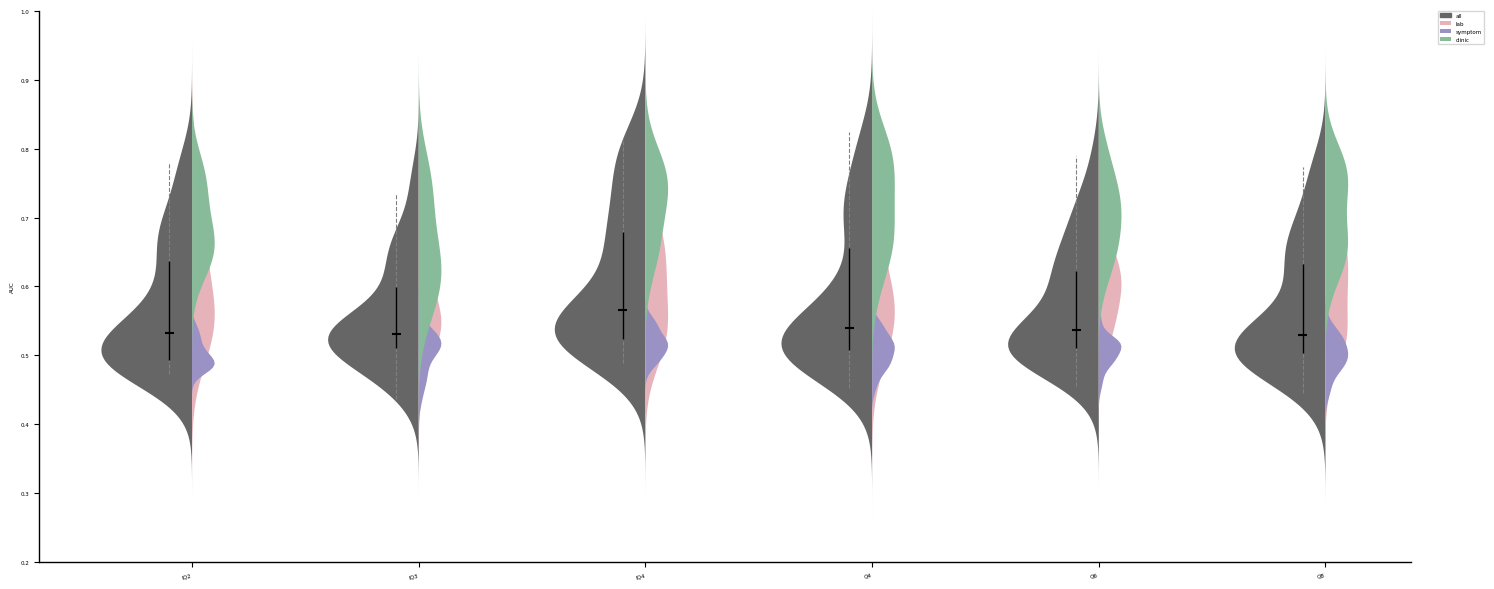

In [6]:
fig=generate_mixed_violin_plot(agg_df_train, 'quantization_level', 0, None, 'Prediction performance by quantization', False, None, False)